<h1>Lab #1 - Object Detection</h1>

<h2></h2>


## Quiz

Bitte bearbeiten Sie folgendes Quiz, bevor Sie mit der Bearbeitung beginnen. Mit diesem können Sie sich Zusatzpunkte für die Klausur erarbeiten. Der Laborversuch wird nicht bewertet.

<img src="images/QUIZ_2026-02_KI_LAB_001.svg" width="200px"></img><br>
https://forms.gle/1QhDCgQitCqd7fPA7

## Vorbereitung

Diese Datei ist ein Jupyter Notebook. Dieses besteht aus Textblöcken im Markdown Format und ausführbaren Code-Zellen. Diese erkennen Sie an dem kleinen Pfeilsymbol links daneben.

Führen Sie bitte als erstes folgende Zelle aus, um sicherzustellen, dass die benötigten Bibliotheken installiert sind:

In [ ]:
!pip install -r requirements.txt

## 1 Motivation

Die automatische Objekterkennung ist eine fundamentale Aufgabe im Bereich Computer Vision und bildet die Grundlage zahlreicher praktischer Anwendungen – von der industriellen Qualitätskontrolle über autonome Robotersysteme bis hin zur Mensch-Maschine-Interaktion. Während klassische Bildverarbeitungsverfahren oft an ihre Grenzen stoßen, sobald Variabilität in Beleuchtung, Perspektive oder Objekterscheinung auftritt, ermöglichen moderne Machine Learning-Ansätze robuste und generalisierbare Lösungen.

In der industriellen Praxis ist es nicht ausreichend, lediglich zu detektieren, *dass* ein Objekt vorhanden ist. Vielmehr müssen präzise Informationen über dessen **Lage, Orientierung und Klasse** extrahiert werden, um beispielsweise einen Robotergreifer korrekt zu positionieren oder Bauteile zu sortieren. Die Herausforderung besteht darin, diese Informationen zuverlässig aus Bilddaten zu gewinnen – selbst unter variierenden Bedingungen.

Dieser Laborversuch vermittelt den vollständigen Workflow einer Machine Learning-basierten Objekterkennung: von der Datenerhebung über das Training neuronaler Netze bis zur Evaluierung und Optimierung. Dabei wird nicht nur theoretisches Wissen vermittelt, sondern Sie erhalten praktische Erfahrung mit den Werkzeugen und Methoden, die in realen Computer Vision-Projekten zum Einsatz kommen.

## 2 Ziel

Das Ziel dieses Laborversuchs ist die Entwicklung eines Machine Learning-Systems zur **Multi-Objekt-Detektion mit Pose-Estimation**. Konkret sollen Sie folgende Kompetenzen erwerben:

### 2.1 Fachliche Ziele
- Entwicklung eines Detektionssystems, das **mehrere Objekte unterschiedlicher Klassen** in einem Bild identifiziert
- Implementierung einer **Keypoint-basierten Pose-Estimation**, wobei jedes Objekt durch **3 charakteristische Keypoints** beschrieben wird, die Lage und Orientierung eindeutig definieren
- Berechnung eines **Objectness-Scores** (Konfidenzwert), der die Sicherheit der Detektion quantifiziert
- Realisierung einer robusten **Multi-Class-Klassifikation**

### 2.2 Methodische Ziele
Sie durchlaufen den **vollständigen Machine Learning Workflow**:
1. **Datenakquise**: Aufnahme und Zusammenstellung eines geeigneten Datensatzes
2. **Datenannotation**: Manuelle Kennzeichnung von Objekten, Klassen und Keypoints
3. **Data Loading**: Implementierung effizienter Datenladeprozesse für das Training
4. **Data Augmentation**: Synthetische Erweiterung des Datensatzes zur Verbesserung der Generalisierung
5. **Model Training**: Training eines neuronalen Netzes auf dem annotierten Datensatz
6. **Evaluierung**: Quantitative Bewertung der Modellleistung mit geeigneten Metriken
7. **Fine Tuning**: Iterative Optimierung von Hyperparametern und Netzarchitektur

Am Ende des Versuchs verfügen Sie über ein funktionsfähiges Objekterkennungssystem und haben praktische Erfahrung mit allen Phasen eines ML-Projekts gesammelt.

## 3 Definition der Datenstruktur

Es soll die Lage und Orientierung von Objekten anhand von 3 Keypoints eindeutig beschrieben werden. Jeder Keypoint ist eine Koordinate im Bild (x, y), wobei sich das Koordinatensystem im Bild oben links befindet:<br>
<img src="images/image_coordinates.png" width="400px"></img>

Die Koordinaten werden als Relativkoordinaten angegeben, um unabhängig von der Bildskalierung zu sein. Befindet sich Keypoint $P_1$ bspw. an Pixelposition $(244, 312)$ in einem Bild mit einer Höhe von 600 Pixeln und einer Breite von 800 Pixeln, so ist die entsprechende Relativkoordinate
$$
    P_1=\begin{pmatrix}
        244px/800px \\
        312px/600px
    \end{pmatrix}=
    \begin{pmatrix}
        0.305 \\
        0.520
    \end{pmatrix}.
$$

Folgende vier Objekttypen sollen im Bild erkannt und klassifiziert werden:

| (0) Bootle Opener - Inlay          | (1) Bootle Opener - Cover           | (2) Bottle Opener             | (3) Cuboid             |
|------------------------------------|-------------------------------------|-------------------------------|------------------------|
| <img src="images/bottle_opener_inlay.png" style="height: 200px; width:auto;"></img> | <img src="images/bottle_opener_cover.png" style="height: 200px; width:auto;"></img> | <img src="images/bottle_opener.png" style="height: 200px; width:auto;"></img> | <img src="images/cuboid.png" style="height: 200px; width:auto;"></img> |
| <img src="images/shapes/Bottle Opener - Inlay.png" style="height: 200px; width:auto;"></img> | <img src="images/shapes/Bottle Opener - Cover.png" style="height: 200px; width:auto;"></img> | <img src="images/shapes/Bottle Opener.png" style="height: 200px; width:auto;"></img> | <img src="images/shapes/Cuboid.png" style="height: 200px; width:auto;"></img> |

_Tabelle 3.1 Objekte_

Die Bilddaten liegen als JPG-Dateien vor. Für jede JPG-Datei wird im selben Verzeichnis eine gleichnamige JSON-Datei erstellt, welche die Annotationen beinhaltet. Jede JSON-Datei beinhaltet eine Liste `[...]` der Objekte im Bild. Jedes Objekt wird durch ein Dictionary `{...}` beschrieben, welches die Attribute `"points"` und `"class"` besitzt. `"points"` ist eine Liste von genau drei Punkten. Das sind die Keypoints in Relativkoordinaten. `"class"` ist ein einzelner `int` Wert, der die Objektklasse (siehe _Tabelle 3.1_) definiert.

**Beispiel:**
```
P1040610.JPG
P1040610.json
    # list of object annotations
    [
        # object dictionary
        {
            "points": [
                [0.711, 0.260],
                [0.583, 0.045],
                [0.493, 0.265]
            ],
            "class": 0
        },
        ...
    ]
```

Weiterhin ist das Datensatzverzeichnis in die Unterverzeichnisse `train`, `val` und `test` unterteilt, wobei alle Daten aus `train` für das Training, alle aus `val` für die Validierung und alle Daten aus `test` für das Testen des Modell verwendet werden.
```
root/
├── train/
│   ├── P1040610.JPG
│   ├── P1040610.json
│   ...
├── val/
│   ├── P1061263.JPG
│   ├── P1061263.json
│   ...
└── test/
    ├── P7835647.JPG
    ├── P7835647.json
    ...
```
Für das Training und die Validierung bekommen Sie bereits annotierte Daten. Ihre Aufgabe wird es sein, die Daten für den Testsplit aufzunehmen, zu annotieren und bereitzustellen. Dazu später mehr.

## 4 Versuchsdurchführung
### 4.1 Datenakquise

Die Datenakquise startet mit der Aufnahme von Bildaten. Für diesen Versuch werden Ihnen Bilder für das Training und die Validierung zur Verfügung gestellt. Diese können unter folgendem Link eingesehen werden: <span style="color:red">TODO: NextCloud Link</span>

**Aufgabe 1**

Erstellen Sie 20 Bilder nach folgenden Kriterien:
- 1 Objekt sichtbar:
  - 2 Bilder, in denen ein _Bottle Opener - Inlay_ zu sehen ist
  - 2 Bilder, in denen ein _Bottle Opener - Cover_ zu sehen ist
  - 2 Bilder, in denen ein _Bottle Opener_ zu sehen ist
  - 2 Bilder, in denen ein _Cuboid_ zu sehen ist
- 2 Objekte sichtbar:
  - 2 Bilder, in denen zwei _Bottle Opener - Inlay_ zu sehen sind
  - 2 Bilder, in denen zwei _Bottle Opener - Cover_ zu sehen sind
  - 2 Bilder, in denen zwei _Bottle Opener_ zu sehen sind
  - 2 Bilder, in denen zwei _Cuboid_ zu sehen sind
- Mindestens 3 Objekte sichtbar:
  - 1 Bild, in dem _Bottle Opener - Inlay_, _Bottle Opener - Cover_, _Bottle Opener_ und _Cuboid_ zu sehen sind
  - 1 Bild, in dem 3 _Bottle Opener - Inlay_ zu sehen sind
  - 1 Bild, in dem 3 _Bottle Opener - Cover_ zu sehen sind
  - 1 Bild, in dem 3 _Bottle Opener_ zu sehen sind
- Variieren Sie die Perspektive zwischen den einzelnen Aufnahmen (Orientierung, Distanz)
- Verwenden Sie möglichst viele unterschiedliche Objekte (bspw. _Bottle Opener - Cover_ mit unterschiedlichen Farben)

**Aufgabe 2**

Führen Sie folgende Codezelle aus, um die grundlegende Verzeichnisstruktur anzulegen. Sie können für `DATASET_DIRECTORY` ein beliebiges Verzeichnis angeben. Wenn Sie diesen Wert auf `"data"` belassen, wird hier ein entsprechendes Unterverzeichnis erstellt.

In [ ]:
from pathlib import Path

DATASET_DIRECTORY = "data"

data_dir = Path(DATASET_DIRECTORY)
for split in ["train", "val", "test"]:
    (data_dir / split).mkdir(parents=True, exist_ok=True)

Stellen Sie nun die von Ihnen aufgenommenen Bilder im Verzeichnis `[DATASET_DIRECTORY]/test` zur Verfügung.

### 4.2 Daten Annotation

Ihnen wird hier ein spezielles OpenCV-basiertes Tool zur Verfügung gestellt, mit dem Sie die aufgenommenen Daten annotieren können. Dieses Tool ermöglicht es, Annotationen für jedes Objekt im Bild anzulegen, die Positionen der Objekt-Keypoints im Bild per Mausklick zu definieren und die Objektklasse zu vergeben.

Die Benutzeroberfläche des Annotationstools besteht aus 4 Hauptbereichen:

1. **Input Image** (links oben)
   - Zeigt das aktuell zu annotierende Bild an
   - Annotationen werden als farbige Überlagerungen dargestellt
   - Die aktuell ausgewählte Annotation ist blau hervorgehoben
   - Keypoints können per Mausklick gesetzt werden

2. **Info-Feld** (rechts oben)
   - Zeigt aktuelle Auswahlebene (`Selected`)
   - **1 - Image**: Aktuelles Bild und Bildnummer
   - **2 - Annotation**: Aktuelle Annotation und Anzahl der Annotationen im Bild
   - **3 - Point**: Aktueller Keypoint und Anzahl der Keypoints in der Annotation
   - **4 - Class**: Aktuelle Objektklasse (0: Bottle Opener - Inlay, 1: Bottle Opener - Cover, 2: Bottle Opener, 3: Cuboid)
   - Fortschrittsanzeige: Anzahl der bereits annotierten Bilder

3. **Vorschaubild** (rechts unten)
   - Zeigt eine transformierte Ansicht der aktuellen Annotation
   - Visualisiert die Keypoint-Positionen relativ zur Objektform
   - Hilft bei der Überprüfung der Annotation

4. **Benutzeraktionen** (unten)
   - Übersicht aller verfügbaren Tastatur- und Mausbefehle
   - Aktive Befehle sind schwarz, inaktive grau dargestellt

#### Bedienung des Annotationstools

**Auswahlbefehle:**
- **1**: Wechsel zur Image-Ebene (Bildauswahl)
- **2**: Wechsel zur Annotation-Ebene (Annotationsauswahl)
- **3**: Wechsel zur Point-Ebene (Keypoint-Auswahl)
- **4**: Wechsel zur Class-Ebene (Klassenauswahl)

**Navigation:**
- **Pfeiltaste Links**: Vorheriges Element (je nach Auswahlebene)
- **Pfeiltaste Rechts** oder **Rechte Maustaste**: Nächstes Element (je nach Auswahlebene)

**Annotationsverwaltung:**
- **+**: Neue Annotation hinzufügen (Kopie der aktuellen Annotation)
- **-**: Aktuelle Annotation löschen

**Keypoint-Bearbeitung (nur bei Point-Ebene aktiv):**
- **Linke Maustaste**: Keypoint an Mausposition im Input Image setzen
- **W, A, S, D**: Keypoint pixelgenau verschieben (W=hoch, A=links, S=runter, D=rechts)

**Weitere Funktionen:**
- **C**: Annotationen ins nächste Bild kopieren
- **N**: Zur nächsten Annotation wechseln (bei Point-Ebene)
- **Q**: Annotation speichern und Tool beenden

**Workflow-Empfehlung:**
1. Bild auswählen (Ebene 1)
2. Objektklasse festlegen (Ebene 4, dann mit Pfeiltasten wechseln)
3. Keypoints setzen (Ebene 3, dann per Mausklick oder WASD positionieren)
4. Bei mehreren Objekten: Mit `+` neue Annotation hinzufügen und Schritte 2-3 wiederholen
5. Mit (1) auf Image-Ebene wechseln und Pfeiltaste rechts, um zum nächsten Bild zu gelangen

<img src="images/annotation_001.png" width=700px></img>

**Aufgabe 3**

Führen Sie folgende Codezelle aus, um mit der Annotation zu beginnen:

In [ ]:
import src.annotate as ann

ann.SKIP_ANNOTATED = True
ann.ANNOTATION_SPLITS = ['train', 'val', 'test']
ann.annotate_dataset(data_dir)

**Data Splits**

In der Regel erfolgt nach der Datenannotation die Aufteilung in verschiedene Datensätze:

- **Train (Trainingsdaten)**: Daten zum Trainieren des Modells (typischerweise 70-80%)
- **Validation (Validierungsdaten)**: Daten zur Hyperparameter-Optimierung und Modellevaluation während des Trainings (typischerweise 10-15%)
- **Test (Testdaten)**: Daten zur finalen Bewertung des trainierten Modells auf ungesehenen Daten (typischerweise 10-15%)

Eine gängige Aufteilung ist beispielsweise 70% Train, 15% Validation und 15% Test.

**Dieser Schritt entfällt hier**, da die Trainings- und Validierungsdaten bereits annotiert und in die entsprechenden Verzeichnisse (`data/train/` und `data/val/`) aufgeteilt bereitgestellt werden.



### 4.3 Data Augmentation

Data Augmentation ist ein essentieller Bestandteil moderner Machine Learning-Pipelines, besonders bei kleineren Datensätzen mit geringer Varianz. Durch künstliche Variation der Trainingsdaten wird der Datensatz synthetisch vergrößert und die Generalisierungsfähigkeit des Modells verbessert. Data Augmentation kann dabei den gleichen Effekt erzielen wie eine tatsächliche Datensatzvergrößerung um den Faktor x, ohne dass neue Daten manuell aufgenommen und annotiert werden müssen:

- **Geometrische Transformationen** (Rotation, Perspektivverzerrung): Das Modell lernt, Objekte unter verschiedenen Blickwinkeln und Orientierungen zu erkennen
- **Farbvariationen** (Helligkeit, Kontrast, Sättigung): Robustheit gegenüber unterschiedlichen Lichtverhältnissen
- **Synthetische Datengenerierung**: Aus einem kleinen annotierten Datensatz werden künstlich viele Variationen erzeugt, was Overfitting reduziert und die Modellrobustheit erhöht

#### 4.3.1 Bild Augmentation
In der folgenden Implementierung werden die Helligkeit, der Kontrast, die Sättigung, der Farbton und die Schärfe des Bildes zufällig manipuliert.

Folgende Zelle visualisiert die einzelnen Bild-Augmentations:

In [ ]:
import src.augmentation as aug
import src.visualization as vis
import src.data as data

sample_name = "images/samples/P1030157.json"

img, points, _ = data.load_record(sample_name)

img_brightness = aug._aug_brithness(img.copy(), 1.3)
img_contrast = aug._aug_contrast(img.copy(), 1.4)
img_saturation = aug._aug_saturation(img.copy(), 1.6)
img_hue = aug._aug_hue(img.copy(), 0.4)
img_sharpness = aug._aug_sharpness(img.copy(), 0.6)
img_random1 = aug.augment_image_numpy(img.copy())
img_random2 = aug.augment_image_numpy(img.copy())
img_random3 = aug.augment_image_numpy(img.copy())

vis.plot_images_with_points(
    [img, img_brightness, img_contrast, img_saturation, img_hue, img_sharpness, img_random1, img_random2, img_random3],
    points_list=[points]*9,
    titles=[
        "Original",
        "Helligkeit +30%",
        "Kontrast +40%",
        "Sättigung +60%",
        "Farbton +40%",
        "Schärfe -40%",
        "Zufällig 1",
        "Zufällig 2",
        "Zufällig 3",
    ]
)

#### 4.3.2 Perspektiv Augmentation

Weiterhin ist es hilfreich, die Perspektive zu variieren, um verschiedene Aufnahmewinkel zu simulieren. Hierbai ist es wichtig, dass die Keypoints der gleichen Perspektivmanipulation unterzogen werden, damit die Targetdaten noch zum Bild passen.

Folgende Zelle visualisiert die einzelnen Perspektiv-Augmentations:

In [ ]:
import src.augmentation as aug
import src.visualization as vis
import src.data as data

sample_name = "images/samples/P1030157.json"
rot1, scale1 = 15, 0.8
rot2, scale2 = -90, 1.2

img, points, _ = data.load_record(sample_name)

img_aug1, points_aug1 = aug.augment_perspective(img, points, distortion=0.15, p=1.0)
img_aug2, points_aug2 = aug.augment_perspective(img, points, distortion=0.15, p=1.0)

vis.plot_images_with_points(
    images=[img, img_aug1, img_aug2],
    points_list=[points, points_aug1, points_aug2],
    titles=[
        f"Originalbild ({0}°, {1.0:.1f}x)",
        f"Augmentiertes Bild (Distortion 0.15)",
        f"Augmentiertes Bild (Distortion 0.15)"
    ]
)

#### 4.3.3 Rotations Augmentation

Bei Bildrotationen müssen die Keypoints ebenfalls rotiert werden.

Folgende Zelle visualisiert die einzelnen Rotations-Augmentations:

In [ ]:
import src.augmentation as aug
import src.visualization as vis
import src.data as data

sample_name = "images/samples/P1030157.json"
rot1, scale1 = 15, 0.8
rot2, scale2 = -90, 1.2

img, points, _ = data.load_record(sample_name)

img_aug1, points_aug1 = aug._augment_rotate(img, points, angle=rot1, scale=scale1)
img_aug2, points_aug2 = aug._augment_rotate(img, points, angle=rot2, scale=scale2)
img_aug3, points_aug3 = aug.augment_rotate(img, points, angle_shift=30, scale_factor=0.2, p=1.0)
img_aug4, points_aug4 = aug.augment_rotate(img, points, angle_shift=30, scale_factor=0.2, p=1.0)
img_aug5, points_aug5 = aug.augment_rotate(img, points, angle_shift=30, scale_factor=0.2, p=1.0)

vis.plot_images_with_points(
    images=[img, img_aug1, img_aug2, img_aug3, img_aug4, img_aug5],
    points_list=[points, points_aug1, points_aug2, points_aug3, points_aug4, points_aug5],
    titles=[
        f"Originalbild ({0}°, {1.0:.1f}x)",
        f"Augmentiertes Bild ({rot1}°, {scale1:.1f}x)",
        f"Augmentiertes Bild ({rot2}°, {scale2:.1f}x)",
        f"Augmentiertes Bild (Zufall)",
        f"Augmentiertes Bild (Zufall)",
        f"Augmentiertes Bild (Zufall)"
    ]
)

### 4.4 Data Loading

Um die annotierten Daten effizient für das Training eines neuronalen Netzes nutzen zu können, wird ein **PyTorch Dataset** implementiert. Diese Klasse übernimmt das Laden der Bilder und Annotationen sowie die Transformation in das für das Modell benötigte Format.

Die Klasse `torch.utils.data.Dataset` dient hierbei als Basisklasse. Dies ist eine abstrakte Klasse, von der unser zu implementierendes `ObjectDataset` ableitet. Folgende Grundstruktur muss in der abgeleiteten Klasse existieren:
```python
from torch.utils.data import Dataset

class ObjectDataset(Dataset):
    def __init__(self):
        """
        Konstruktor der Klasse -> dient zur Initialisierung
        I. d. R. erfolgt hier das Einlesen der verfügbaren Daten
        """
        # your code here

    def __len__(self):
        """Gibt die Anzahl der im dataset enthaltenen Items zurück."""
        # your code here

    def __getitem__(self, idx):
        """
        Gibt das Item an der Stelle idx zurück. In unserem Fall ist das der
        Input Tensor x (das augmentierte Bild) und ein Target dictionary, welches
        Tensoren für bounding boxen, Klassenlabels und Keypoints enthält.
        """
        # your code here
```



In [ ]:
import src.data as data

data.download_dataset(force_download=True)

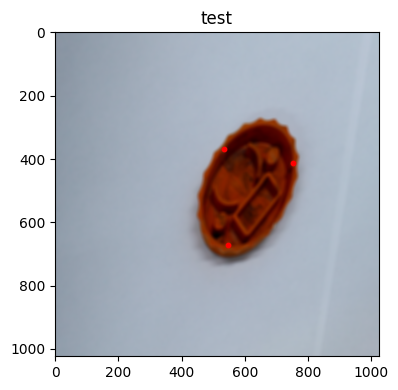

In [9]:
import torch
import torchvision
from torch.utils.data import Dataset
import src.data as data
import src.augmentation as aug
import src.visualization as vis
from pathlib import Path
import json
import cv2 as cv
from typing import Tuple

class ObjectDataset(Dataset):
    def __init__(
            self,
            split:str,
            image_size:Tuple[int, int]=(1024, 1024)
        ):
        super().__init__()

        assert split in ["train", "val", "test"], "Ungültiger Split. Erlaubt sind 'train', 'val' und 'test'."
       
        self.split = split
        self.annotations = data.load_annotations(split=split)
        self.image_size = image_size

    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, index):
        ann = self.annotations[index]
        img = cv.imread(ann["img_file"]) / 255.
        img = cv.resize(img, self.image_size)

        w, h = self.image_size
        keypoints = ann["points"]

        if self.split == "train":
            img, keypoints = aug.augment_perspective(img, keypoints, distortion=0.2, p=0.5)
            img, keypoints = aug.augment_rotate(img, keypoints, angle_shift=30, scale_factor=0.2, p=0.5)
            img = aug.augment_image_numpy(img)

        boxes = []
        N_obj = keypoints.shape[0] // 3
        for kpts in keypoints.copy().reshape(N_obj, 3, 2):
            xmin, xmax = kpts[:, 0].min(), kpts[:, 0].max()
            ymin, ymax = kpts[:, 1].min(), kpts[:, 1].max()
            boxes.append([xmin, ymin, xmax, ymax])

        img = torch.tensor(img).permute(2, 0, 1).float()
        img = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )(img)

        target = {
            "boxes": torch.tensor(boxes).float(),
            "keypoints": torch.tensor(keypoints).float(),
            "labels": torch.tensor(ann["classes"]) + 1  # +1, because background class = 0
        }

        return img, target

ds_train = ObjectDataset(split="train")
for record in ds_train:
    img, target = record
    
    vis.plot_images_with_points([img], [target["keypoints"]], ['test'])
    pass

In [ ]:
from torch.utils.data import Dataset
import torch
import torchvision
import cv2 as cv

class RCNNDataset(Dataset):
    def __init__(
            self,
            dataset_directory:str,
            split:str,
            image_size:tuple = (512, 512)
    ):
        assert split in ['train', 'val', 'test'], "Split must be 'train', 'val' or 'test'"

        self.dataset_directory = Path(dataset_directory)
        self.split = split
        self.image_size = image_size

        self.transforms = torchvision.transforms.Compose([
            torchvision.transforms.Resize(self.image_size),
            torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.annotations = []
        self._sampled_classes = {}

        self.__load__()

    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, index):
        ann_coco = self.annotations[index]
        img_file = ann_coco['img_file']
        
        # Originalbild laden
        img = cv.imread(img_file) / 255
        
        # Resize
        img = cv.resize(img, self.image_size)
        new_h, new_w, _ = img.shape
        
        # Keypoints und Boxes skalieren
        keypoints = ann_coco['keypoints'].copy()
        keypoints[:, :, 0] *= new_w  # x
        keypoints[:, :, 1] *= new_h  # y

        boxes = []
        if self.split == 'train':
            # Datenaugmentation
            kpts = keypoints.copy()[:, :, 0:2].reshape(-1, 2)

            img, kpts = augment_rotate(img, kpts, angle_range=(-30,30), scale_range=(0.8,1.2), p=0.5)
            img, kpts = augment_perspective(img, kpts, distortion=0.1, p=10.5)

            kpts = kpts.reshape(-1, 3, 2)
            keypoints[:, :, 0:2] = kpts

            img = augment_image_numpy(img)

        for kpts in keypoints:
            xmin, xmax = kpts[:, 0].min(), kpts[:, 0].max()
            ymin, ymax = kpts[:, 1].min(), kpts[:, 1].max()
            boxes.append([xmin, ymin, xmax, ymax])

        img = torch.tensor(img).permute(2,0,1).float()  # HWC -> CHW
        
        # Normalisierung
        img = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )(img)

        for label in ann_coco['labels']:
            self._sampled_classes[label] = self._sampled_classes.get(label, 0) + 1
        
        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(ann_coco['labels'], dtype=torch.int64),
            'keypoints': torch.tensor(keypoints, dtype=torch.float32)
        }
        
        return img, target

    def __load__(self):
        self.class_cnts = {}
        #self.annotation_files = []
        for ann_file in tqdm(list((self.dataset_directory / self.split).rglob('*.json')), desc=f'Loading {self.split} annotations', leave=False):
            if ann_file.with_suffix('.JPG').exists():
                ann_coco = self.__load_annotation__(ann_file)
                for label in ann_coco['labels']:
                    self.class_cnts[label] = self.class_cnts.get(label, 0) + 1
                self.annotations.append(ann_coco)
        # Split-Filter hinzufügen!
        #annotation_files = list((self.dataset_directory / self.split).rglob('*.json'))
    
    def __load_annotation__(self, ann_file):
        def annotations2coco(annotations):
            #boxes = []
            labels = []
            keypoints = []

            for obj in annotations:
                class_idx = obj['class'] + 1
                pts = np.array(obj['points'], dtype=np.float32)
                
                # Pixel-Koordinaten
                # pts_pixel = pts.copy()
                # pts_pixel[:, 0] *= img_width
                # pts_pixel[:, 1] *= img_height
                
                # Keypoints
                # kpts = []
                # for x, y in pts_pixel:
                #     kpts.extend([x, y, 2])
                pts = np.hstack((pts, np.full((pts.shape[0], 1), 2)))  # Sichtbar
                
                labels.append(class_idx)
                keypoints.append(pts)

            return {
                #'boxes': np.array(boxes, dtype=np.float32),
                'labels': np.array(labels, dtype=np.int64),
                'keypoints': np.array(keypoints, dtype=np.float32).reshape(-1, 3, 3)
            }

        self.annatations = []
        
        #for ann_file in tqdm(annotation_files, desc=f'Loading {self.split} annotations', leave=False):
        img_file = str(ann_file).replace('.json', '.JPG')
        
        with open(ann_file, 'r') as f:
            ann = json.load(f)
            # if len(ann) == 0:  # Keine Objekte
            #     continue
            ann_coco = annotations2coco(ann)
            ann_coco['img_file'] = img_file
            ann_coco['ann_file'] = str(ann_file)
            #self.annatations.append(ann_coco)

        return ann_coco

    def get_weighted_sampler(self):
        """Erstellt Sampler basierend auf der seltensten Klasse pro Bild"""
        from collections import Counter
        
        # Zähle Objekte pro Klasse
        class_counts = Counter()
        for ann in self.annotations:
            for label in ann['labels']:
                class_counts[label] += 1
        
        print(f"\nClass distribution: {dict(class_counts)}")
        
        # Berechne Gewichte (inverse frequency)
        total = sum(class_counts.values())
        class_weights = {}
        for label, count in class_counts.items():
            class_weights[label] = total / (len(class_counts) * count)
        
        print(f"Class weights: {class_weights}")
        
        # Jedes Bild bekommt das HÖCHSTE Gewicht seiner Klassen
        sample_weights = []
        for ann in self.annotations:
            labels = ann['labels']
            # Nutze die seltenste Klasse im Bild
            weights = [class_weights[label] for label in labels]
            sample_weights.append(max(weights))
        
        return torch.utils.data.WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )